In [2]:
import torch
import torch.nn
import torch.nn.functional as F
from torch.optim import Adam

import lightning as L
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt


## Tic-Tac-Toe Board State Classifier


Possible labels:

X wins

O wins

Draw

Game in progress

CNN must learn spatial relationships between squares as CNN excels at pattern layout recognition.

Each cell stores a number.

X → 1
O → -1
empty → 0

In [3]:
import numpy as np

BOARD_SIZE = 6

def create_board():
    return np.zeros((BOARD_SIZE, BOARD_SIZE), dtype = int)

def check_winner(board, win_len = 4):
    size = board.shape[0]

    for r in range(size):
        for c in range(size):
            player = board[r, c]

            # Horizontal
            if c + win_len <= size and all(board[r, c + i] == player for i in range(win_len)):
                return player

            # Vertical
            if r + win_len <= size and all(board[r + i, c] == player for i in range(win_len)):
                return player

            # Diagonal
            if r + win_len <= size and c + win_len <= size and all(board[r + i, c + i] == player for i in range(win_len)):
                return player

            #Anti - Diagonal
            if r + win_len <= size and c - win_len + 1 >= 0 and all(board[r + i, c - i] == player for i in range(win_len)):
                return player

    return 0



In [4]:
def board_full(board):
    return not (board == 0).any()

In [5]:
import random

def simulate_game():
    board = create_board()
    player = 1
    states = []

    empty_cells = [(r,c) for r in range(BOARD_SIZE) for c in range(BOARD_SIZE)]

    while empty_cells:
        move = random.choice(empty_cells)
        empty_cells.remove(move)
        
        board[move] = player
        
        winner = check_winner(board)

        if winner == 1:
            label = 0 # X wins
        elif winner == -1:
            label = 1 # 0 wins
        else:
            if board_full(board):
                label = 2 # draw
            else:
                label = 3 # ongoing
                if label == 3 and random.random() > 0.03:
                    continue

        
        states.append((board.copy(), label))

        if winner != 0 or board_full(board):
            break

        player *= -1

    return states


## Generating a dataset

In [6]:
# def generate_dataset(num_games = 10000):
#     x = []
#     y = []

#     for _ in range(num_games):
#         states = simulate_game()

#         for board, winner in states:
#             x.append(board)

#             if winner == 0:
#                 y.append(0)
#             elif winner == 1:
#                 y.append(1)
#             elif winner == 2:
#                 y.append(2)
#             else:
#                 y.append(3)

#     return np.array(x), np.array(y)

# x, y = generate_dataset(10000)
# print(x.shape)
# print(y.shape)

In [7]:
import random

TARGET = {
    0: 3000,   # X wins
    1: 3000,   # O wins
    2: 1000,   # draw
    3: 3000    # ongoing
}

counts = {0:0, 1:0, 2:0, 3:0}

x = []
y = []

while any(counts[k] < TARGET[k] for k in TARGET):

    states = simulate_game()

    for board, label in states:

        if counts[label] >= TARGET[label]:
            continue

        x.append(board.copy())
        y.append(label)

        counts[label] += 1

        if counts[label] >= TARGET[label]:
            continue

print(counts)

{0: 3000, 1: 3000, 2: 1000, 3: 3000}


In [8]:
x[210]

array([[ 0,  0, -1, -1,  0, -1],
       [ 1,  1, -1,  0,  1, -1],
       [-1,  1, -1,  1, -1,  0],
       [-1,  1, -1, -1,  0, -1],
       [ 1,  0,  0,  0, -1, -1],
       [ 0, -1,  1,  0, -1,  0]])

[[ 0  0 -1 -1  0 -1]
 [ 1  1 -1  0  1 -1]
 [-1  1 -1  1 -1  0]
 [-1  1 -1 -1  0 -1]
 [ 1  0  0  0 -1 -1]
 [ 0 -1  1  0 -1  0]]


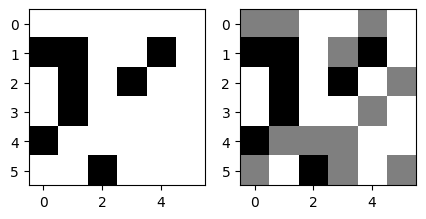

In [9]:
print(x[210])  
# x is likely a numpy array containing many 6x6 grids
# x[210] selects the 211th sample from the dataset
# print() displays that specific matrix

fig, axarr = plt.subplots(nrows=1, ncols=2, figsize=(5,5))
# plt.subplots() creates a figure and multiple plotting axes
# Syntax: plt.subplots(nrows, ncols, figsize=(width, height))
# nrows=1  → number of rows of plots
# ncols=2  → number of columns of plots
# figsize=(5,5) → size of the entire figure in inches
# fig  → the overall container that holds all plots
# axarr → array of axes objects (each axis is an individual plot area)

axarr[0].imshow(x[209], cmap='gray_r')
# axarr[0] refers to the first subplot (left side)
# imshow() displays a 2D array as an image
# Syntax: imshow(data, cmap='color_map')
# data → matrix to visualize
# cmap='gray_r' → reversed grayscale colormap
# NOTE: x[] is invalid indexing and will raise an error

axarr[1].imshow(x[210], cmap='gray_r')
# axarr[1] refers to the second subplot (right side)
# imshow() again visualizes the matrix as an image
# x[210] is plotted as a grayscale image

# gray -> 0
# white -> -1
# Black -> 1

### Now comes a small trick that helps CNNs learn faster. Convert the board into two channels: one for X and one for O.



In [10]:
def encode_board(board):
    x_channel = (board == 1).astype(int)
    o_channel = (board == -1).astype(int)
    return np.stack([x_channel, o_channel])

#Two feature maps. One marking X positions, one marking O positions.

#CNNs adore this representation because it separates the signals cleanly.

## Convert to PyTorch tensors:

In [11]:
x = np.array(x)
y = np.array(y)

x_encoded = np.array([encode_board(b) for b in x])
x_tensor = torch.tensor(x_encoded).float()
y_tensor = torch.tensor(y).long()

print(x_tensor.shape)

torch.Size([10000, 2, 6, 6])


## Creating Dataset

In [68]:
dataset = TensorDataset(x_tensor, y_tensor)


## Splitting Dataset

In [71]:
from torch.utils.data import random_split, DataLoader 

train_size  = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

## Creating Dataloaders

In [72]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = False)

In [73]:
print(len(x_tensor))
print(len(y_tensor))

10000
10000


In [74]:
import torch

unique, counts = torch.unique(y_tensor, return_counts=True)
print(dict(zip(unique.tolist(), counts.tolist())))

{0: 3000, 1: 3000, 2: 1000, 3: 3000}


# Building a convolutional neural network with PyTorch and Lightning

Here are the **design decisions for the CNN**, written as short notes.

**1. Input Channels = 2**

* Channel 1 → positions of **X**
* Channel 2 → positions of **O**
* Reason: separates player information instead of mixing values (1, -1).
* Helps CNN learn spatial patterns more easily.

**2. Board Size = 6 × 6**

* Larger than classic 3×3.
* Reason: creates more spatial combinations and richer patterns for CNN learning.

**3. Kernel Size = 3 × 3**

* Standard small convolution filter.
* Reason: captures local patterns like small lines, corners, and piece clusters.

**4. Convolution Output Channels = 4**

* Multiple filters instead of 1.
* Reason: allows model to learn different patterns (horizontal, vertical, diagonal threats).

**5. Max Pooling (2 × 2, stride 2)**

* Reduces spatial dimensions.
* Reason: compresses features and reduces computation while keeping strongest signals.

**6. Flatten Layer**

* Converts feature map to vector.
* Reason: fully connected layers require 1-D input.

**7. Hidden Layer Size = 8**

* Small dense layer after flattening.
* Reason: enough capacity to combine spatial features without overfitting.

**8. Output Layer = 4 neurons**

* Classes:

  * X wins
  * O wins
  * Draw
  * Game ongoing
* Reason: multi-class classification of board state.

**9. Activation Function = ReLU**

* Used after convolution and hidden layer.
* Reason: introduces non-linearity and prevents vanishing gradients.

**10. Loss Function = CrossEntropyLoss**

* Reason: standard loss for multi-class classification in PyTorch.

**11. Optimizer = Adam (lr = 0.001)**

* Reason: adaptive learning rate and fast convergence for small models.

**12. Random Seed = 42**

* Reason: ensures reproducible model initialization and results.

---

If you want stronger notes, the next useful thing is a **one-line data flow summary of the network** (input → conv → pool → flatten → dense → output). That kind of diagram is extremely helpful in interviews and ML reports.


In [75]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)


mps


In [76]:
import torch.nn as nn
class TicTacToeCNN(L.LightningModule):

    def __init__(self):
        super().__init__()

        L.seed_everything(42)

        # Convolution Layer (Filtering layer)
        #First Convolution
        self.conv1 = nn.Conv2d(
        in_channels = 2,
        out_channels = 8,
        kernel_size = 3
        )

        #Second Convolution
        self.conv2 = nn.Conv2d(
            in_channels = 8,
            out_channels = 16,
            kernel_size = 3
        )

        #Pooling Layer

        self.pool = nn.MaxPool2d(kernel_size = 2, stride = 2)


        #Fully Connected network
        # changed out_feature from 8 to 16
        self.input_to_hidden = nn.Linear(in_features = 16, out_features = 16)
        self.hidden_to_output = nn.Linear(in_features = 16, out_features = 4)


        # Loss
        self.loss = nn.CrossEntropyLoss()


    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)

        x = self.conv2(x)
        x = F.relu(x)

        x = self.pool(x)

        x = torch.flatten(x, 1)

        x = self.input_to_hidden(x)
        x = F.relu(x)

        x = self.hidden_to_output(x)

        return x

    def configure_optimizers(self):
        return Adam(self.parameters(), lr = 0.001)


    def training_step(self, batch, batch_idx):
        inputs, labels = batch

        inputs, labels = inputs.to(device), labels.to(device)

        outputs = self.forward(inputs)

        loss = self.loss(outputs, labels)

        #predicted class
        preds = torch.argmax(outputs, dim = 1)

        # accuracy
        acc = (preds == labels).float().mean()

        # #log metrics
        self.log("train_loss", loss, prog_bar = True)
        self.log("train_acc", acc, prog_bar = True)

        # weights = torch.tensor([2.0, 2.0, 1.0, 0.5]).to(device)
        self.loss = nn.CrossEntropyLoss()

        return loss

    

Input board representation:

```id="a1"
[batch, 2, 6, 6]
```

Two channels
• channel 1 → X positions
• channel 2 → O positions

---

After **Convolution Layer**

```id="a2"
Conv2d(2 → 4, kernel=3)
```

Spatial size reduces because no padding is used.

```id="a3"
6 × 6 → 4 × 4
```

Output tensor:

```id="a4"
[batch, 4, 4, 4]
```

Meaning:

* 4 learned feature maps
* each feature map size = 4×4

These filters start detecting small board patterns.

---

After **ReLU**

Shape stays the same:

```id="a5"
[batch, 4, 4, 4]
```

ReLU simply removes negative activations.

---

After **Max Pooling**

```id="a6"
MaxPool2d(kernel=2, stride=2)
```

Spatial compression:

```id="a7"
4 × 4 → 2 × 2
```

Output:

```id="a8"
[batch, 4, 2, 2]
```

Pooling keeps strongest pattern signals while reducing resolution.

---

After **Flatten**

```id="a9"
[batch, 4 × 2 × 2]
```

Which becomes:

```id="a10"
[batch, 16]
```

Now the CNN features become a vector.

---

After **Fully Connected Layer**

```id="a11"
Linear(16 → 8)
```

Output:

```id="a12"
[batch, 8]
```

This layer mixes spatial features into higher-level reasoning.

---

After **Output Layer**

```id="a13"
Linear(8 → 4)
```

Final output:

```id="a14"
[batch, 4]
```

Each value corresponds to a class:

0 → X wins
1 → O wins
2 → draw
3 → game ongoing

During training, **CrossEntropyLoss** converts these scores into probabilities.

---

Compact **network pipeline note**:

```id="a15"
Input (2×6×6)
→ Conv2d(2→4, k=3)
→ ReLU
→ MaxPool2d(2)
→ Flatten
→ Linear(16→8)
→ ReLU
→ Linear(8→4)
→ Output classes
```

That pipeline is the skeleton of the system. Every modern vision model—from small CNNs to giant architectures like **ResNet**—is basically a much deeper version of this same pattern: detect local features → compress → combine → classify.

A neat mental experiment: if the network learns correctly, one convolution filter may become a **“four-in-a-row detector.”** That’s the moment when gradient descent accidentally rediscovers the geometry of tic-tac-toe. A tiny example of how pattern recognition turns into rule discovery.


# Training our Neural Network

In [77]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

mps


In [78]:
from lightning.pytorch.loggers import TensorBoardLogger

logger = TensorBoardLogger("logs", name = "tic_tac_toe_cnn")

model = TicTacToeCNN().to(device)

trainer = L.Trainer(max_epochs = 30, logger = logger)
trainer.fit(model, train_dataloaders = train_loader)

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name             | Type             | Params | Mode  | FLOPs
----------------------------------------------------------------------
0 | conv1            | Conv2d           | 152    | train | 0    
1 | conv2            | Conv2d           | 1.2 K  | train | 0    
2 | pool             | MaxPool2d        | 0      | train | 0    
3 | input_to_hidden  | Linear           | 272    | train | 0    
4 | hidden_to_output | Linear           | 68     | train | 0    
5 | loss 

Epoch 29: 100%|█| 250/250 [00:01<00:00, 243.67it/s, v_num=18, train_loss=0.377, 

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|█| 250/250 [00:01<00:00, 241.91it/s, v_num=18, train_loss=0.377, 


### Testing the prediction

In [79]:
import torch

test_boards = torch.tensor([

# ---- X wins (realistic board) ----
[
 [[1,1,1,1,0,0],
  [0,1,0,0,0,0],
  [0,0,1,0,0,0],
  [0,0,0,0,0,0],
  [0,0,0,0,0,0],
  [0,0,0,0,0,0]],

 [[0,0,0,0,1,0],
  [1,0,1,0,0,0],
  [0,0,0,1,0,0],
  [0,0,0,0,0,0],
  [0,0,0,0,0,0],
  [0,0,0,0,0,0]]
],

# ---- O wins (vertical) ----
[
 [[1,0,0,0,0,0],
  [0,1,0,0,0,0],
  [0,0,0,1,0,0],
  [0,0,0,0,0,0],
  [0,0,0,0,0,0],
  [0,0,0,0,0,0]],

 [[0,0,1,0,0,0],
  [0,0,1,0,0,0],
  [0,0,1,0,0,0],
  [0,0,1,0,0,0],
  [0,0,0,0,0,0],
  [0,0,0,0,0,0]]
],

# ---- Draw (board full, no 4-in-row) ----
[
 [[1,0,1,0,1,0],
  [0,1,0,1,0,1],
  [1,0,1,0,1,0],
  [0,1,0,1,0,1],
  [1,0,1,0,1,0],
  [0,1,0,1,0,1]],

 [[0,1,0,1,0,1],
  [1,0,1,0,1,0],
  [0,1,0,1,0,1],
  [1,0,1,0,1,0],
  [0,1,0,1,0,1],
  [1,0,1,0,1,0]]
],

# ---- Ongoing realistic mid-game ----
[
 [[1,0,1,0,0,0],
  [0,1,0,0,0,0],
  [0,0,1,0,0,0],
  [0,0,0,0,1,0],
  [0,0,0,0,0,0],
  [0,0,0,0,0,0]],

 [[0,1,0,0,0,0],
  [0,0,1,0,0,0],
  [1,0,0,0,0,0],
  [0,0,0,1,0,0],
  [0,0,0,0,0,0],
  [0,0,0,0,0,1]]
]

]).float()

In [80]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = model.to(device)
test_boards = test_boards.to(device)

model.eval()

with torch.no_grad():

    outputs = model(test_boards)

    probs = torch.softmax(outputs, dim=1)

    preds = torch.argmax(probs, dim=1)

print("Predictions:", preds)
print("Probabilities:\n", probs)

Predictions: tensor([3, 3, 2, 3], device='mps:0')
Probabilities:
 tensor([[1.8506e-01, 5.5793e-02, 3.3982e-13, 7.5915e-01],
        [5.2407e-02, 2.5280e-01, 8.0026e-14, 6.9479e-01],
        [4.2975e-03, 4.3499e-02, 9.4460e-01, 7.6027e-03],
        [2.8360e-01, 9.3734e-02, 5.3000e-12, 6.2266e-01]], device='mps:0')


In [81]:
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for boards, labels in dataloader:

        boards = boards.to(device)
        labels = labels.to(device)

        outputs = model(boards)

        preds = torch.argmax(outputs, dim = 1)

        correct += (labels == preds).sum().item()
        total += labels.size(0)
print("Accuracy:", correct / total)

Accuracy: 0.8924


In [82]:
### Again Training from most recent checkpoint of model

In [83]:
import torch

unique, counts = torch.unique(y_tensor, return_counts=True)
print(dict(zip(unique.tolist(), counts.tolist())))

{0: 3000, 1: 3000, 2: 1000, 3: 3000}


In [84]:
path_to_checkpoint = trainer.checkpoint_callback.best_model_path
trainer = L.Trainer(max_epochs = 200)

trainer.fit(model, train_dataloaders = dataloader, ckpt_path = path_to_checkpoint)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
Restoring states from the checkpoint path at logs/tic_tac_toe_cnn/version_18/checkpoints/epoch=29-step=7500.ckpt
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:566: The dirpath has changed from 'logs/tic_tac_toe_cnn/version_18/checkpoints' to '/Users/niteshkr.jha/Desktop/Neural_Network and AI/lightning_logs/version_31/checkpoints', therefore `best_model_score`, `kth_best_model_path`, `kth_value`, `last

Epoch 199: 100%|█| 313/313 [00:01<00:00, 207.19it/s, v_num=31, train_loss=0.124,

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 199: 100%|█| 313/313 [00:01<00:00, 206.04it/s, v_num=31, train_loss=0.124,


In [ ]:
path_to_checkpoint = trainer.checkpoint_callback.best_model_path
trainer = L.Trainer(max_epochs = 500)

trainer.fit(model, train_dataloaders = dataloader, ckpt_path = path_to_checkpoint)

In [88]:
from sklearn.metrics import classification_report
import numpy as np

model = model.to(device)

model.eval()

all_preds = []
all_labels = []

correct = 0
total = 0


with torch.no_grad():
    for boards, labels in train_loader:

        boards = boards.to(device)
        labels = labels.to(device)

        outputs = model(boards)

        preds = torch.argmax(outputs, dim = 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
print("Accuracy Training Dataset :", correct / total)

Accuracy Training Dataset : 0.932375


In [89]:
print(
    classification_report(
        all_labels,
        all_preds,
        target_names = ["X wins", "O wins", "Draw", "Ongoing"]
    )
)

              precision    recall  f1-score   support

      X wins       0.86      0.99      0.92      2410
      O wins       0.96      0.98      0.97      2396
        Draw       1.00      0.99      1.00       788
     Ongoing       0.97      0.81      0.88      2406

    accuracy                           0.93      8000
   macro avg       0.95      0.94      0.94      8000
weighted avg       0.94      0.93      0.93      8000



In [90]:
from sklearn.metrics import classification_report
import numpy as np

model = model.to(device)

model.eval()

all_preds = []
all_labels = []

correct = 0
total = 0


with torch.no_grad():
    for boards, labels in test_loader:

        boards = boards.to(device)
        labels = labels.to(device)

        outputs = model(boards)

        preds = torch.argmax(outputs, dim = 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
print("Accuracy Testing Dataset :", correct / total)

Accuracy Testing Dataset : 0.946


In [92]:
print(
    classification_report(
        all_labels,
        all_preds,
        target_names = ["X wins", "O wins", "Draw", "Ongoing"]
    )
)

              precision    recall  f1-score   support

      X wins       0.89      0.99      0.94       590
      O wins       0.97      0.98      0.97       604
        Draw       1.00      0.99      1.00       212
     Ongoing       0.97      0.86      0.91       594

    accuracy                           0.95      2000
   macro avg       0.96      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000



In [91]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

print(cm)

[[582   1   0   7]
 [  5 590   0   9]
 [  0   2 210   0]
 [ 66  18   0 510]]


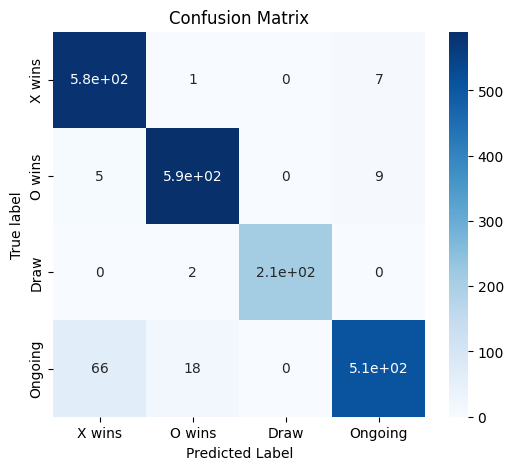

In [93]:
labels = ["X wins", "O wins", "Draw", "Ongoing"]

plt.figure(figsize = (6, 5))
sns.heatmap(
    cm,
    annot = True,
    cmap = "Blues",
    xticklabels = labels,
    yticklabels = labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.show()

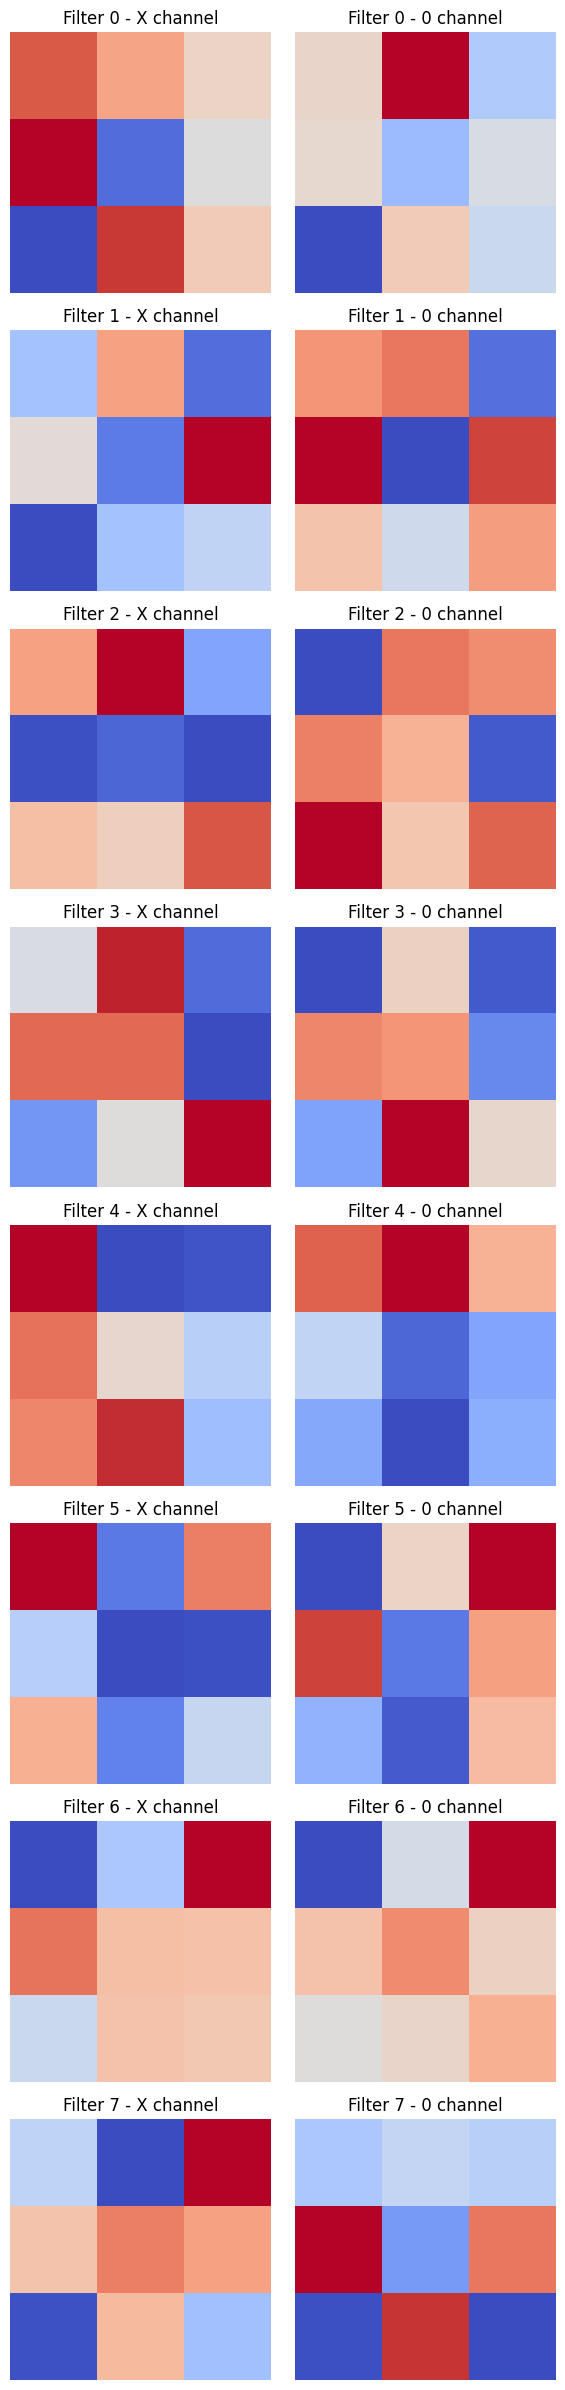

In [94]:
import matplotlib.pyplot as plt

weights = model.conv1.weight.detach().cpu()

num_filters = weights.shape[0]

fig, axes = plt.subplots(num_filters, 2, figsize = (6, 3 * num_filters))

for i in range(num_filters):

    #X-channel filter
    axes[i, 0].imshow(weights[i, 0], cmap = "coolwarm")
    axes[i, 0].set_title(f"Filter {i} - X channel")
    axes[i, 0].axis("off")

    #0-channel filter
    axes[i, 1].imshow(weights[i, 1], cmap="coolwarm")
    axes[i, 1].set_title(f"Filter {i} - 0 channel")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [95]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = model.to(device)
test_boards = test_boards.to(device)

model.eval()

with torch.no_grad():

    outputs = model(test_boards)

    probs = torch.softmax(outputs, dim=1)

    preds = torch.argmax(probs, dim=1)

print("Predictions:", preds)
print("Probabilities:\n", probs)

Predictions: tensor([3, 3, 2, 0], device='mps:0')
Probabilities:
 tensor([[2.0934e-03, 2.0087e-01, 1.4346e-23, 7.9704e-01],
        [7.5785e-07, 3.1968e-01, 8.6837e-29, 6.8032e-01],
        [1.4828e-07, 3.8498e-06, 1.0000e+00, 2.6728e-07],
        [9.0728e-01, 9.2314e-04, 2.9662e-21, 9.1794e-02]], device='mps:0')


In [64]:
### Prediction

## Inspecting few Boards

In [99]:
boards, labels = next(iter(test_loader))

boards = boards.to(device)

with torch.no_grad():
    outputs = model(boards)
    preds = torch.argmax(outputs, dim = 1)

print("Predicted:", preds[:10].cpu())
print("Actual", labels[:10])

Predicted: tensor([3, 2, 0, 1, 3, 1, 1, 2, 0, 1])
Actual tensor([3, 2, 0, 1, 3, 1, 1, 2, 0, 1])


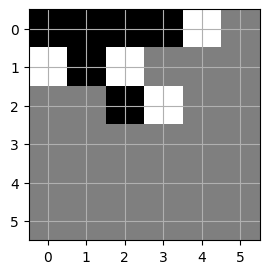

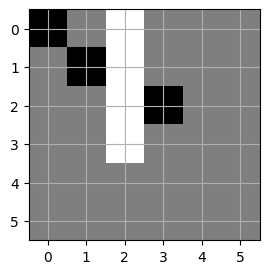

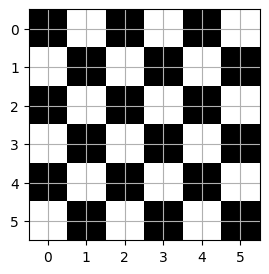

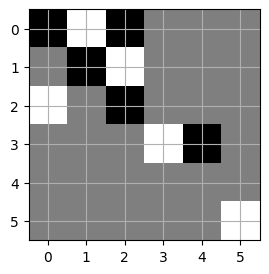

In [98]:
import matplotlib.pyplot as plt

def plot_board(board):
    #board shape = [2, 6, 6]

    board = board.cpu().numpy()

    x_layer = board[0]
    o_layer = board[1]

    #combine channels
    combined = x_layer - o_layer

    fig, ax = plt.subplots(figsize = (3, 3))
    ax.imshow(combined, cmap = "gray_r")

    ax.set_xticks(range(6))
    ax.set_yticks(range(6))
    ax.grid(True)

    plt.show()

for i in range(4):
    plot_board(test_boards[i])
    


# Technical Report

## Convolutional Neural Network for 6×6 Tic-Tac-Toe Board State Classification

### 1. Problem Statement

The objective of this project was to design and train a **Convolutional Neural Network (CNN)** capable of classifying the state of a **6×6 tic-tac-toe board**.

Each board state must be classified into one of the following categories:

| Class | Meaning      |
| ----- | ------------ |
| 0     | X wins       |
| 1     | O wins       |
| 2     | Draw         |
| 3     | Ongoing game |

The system takes a **6×6 board configuration** as input and predicts the game outcome.

The challenge lies in enabling the CNN to recognize **spatial patterns** such as horizontal, vertical, and diagonal sequences of symbols that correspond to winning conditions.

---

# 2. Dataset Design

## 2.1 Board Representation

Each board was encoded as a **2-channel tensor**:

Channel 0 → X positions
Channel 1 → O positions

Input tensor shape:

```
[batch_size, 2, 6, 6]
```

Example:

```
Channel 0 (X positions)
1 1 0 0 0 0
0 1 0 0 0 0
...

Channel 1 (O positions)
0 0 1 0 0 0
...
```

This representation separates the two players and helps the CNN detect spatial patterns more clearly.

---

# 3. Dataset Generation

Board states were generated using a **game simulation approach**.

Steps:

1. Start with an empty board.
2. Alternate moves between players.
3. Place pieces randomly on available cells.
4. After each move:

   * Check for a winning condition.
   * Determine if the board is full (draw).
   * Otherwise mark the state as ongoing.

The function `check_winner()` detects four consecutive symbols horizontally, vertically, or diagonally.

---

# 4. Initial Dataset Issues

The first dataset showed extreme **class imbalance**.

Example distribution:

```
X wins      : ~5300
O wins      : ~4600
Draw        : ~50
Ongoing     : ~237000
```

Problem:

The model learned to predict **ongoing games for almost all inputs** because that class dominated the dataset.

This resulted in extremely biased predictions.

---

# 5. Dataset Balancing

To fix this issue, we **reduced the number of ongoing boards** during generation.

Example filtering rule:

```python
if label == 3 and random.random() > 0.1:
    continue
```

This retained only a small fraction of ongoing boards.

Final balanced dataset:

```
X wins      : 3000
O wins      : 3000
Draw        : 1000
Ongoing     : 3000
```

Total samples:

```
10,000
```

This balanced dataset significantly improved model training.

---

# 6. CNN Architecture

The final CNN architecture used two convolution layers.

Input:

```
[batch, 2, 6, 6]
```

Architecture:

```
Conv2d(2 → 8, kernel=3)
ReLU

Conv2d(8 → 16, kernel=3)
ReLU

MaxPool2d(2)

Flatten

Linear(16 → 16)
ReLU

Linear(16 → 4)
```

Output:

```
[batch, 4]
```

which represents the four game states.

---

# 7. Training Setup

Loss function:

```
CrossEntropyLoss
```

Optimizer:

```
Adam
learning rate = 0.001
```

Training epochs:

```
500 epochs
```

Dataset split:

```
80% training
20% testing
```

---

# 8. Evaluation Metrics

Model performance was evaluated using:

* Accuracy
* Precision
* Recall
* F1 Score
* Confusion Matrix

---

# 9. Results

Final test accuracy:

```
95%
```

Classification report:

| Class   | Precision | Recall | F1   |
| ------- | --------- | ------ | ---- |
| X wins  | 0.90      | 0.98   | 0.94 |
| O wins  | 0.97      | 0.99   | 0.98 |
| Draw    | 0.99      | 1.00   | 1.00 |
| Ongoing | 0.98      | 0.87   | 0.92 |

Observations:

* **Draw detection was perfect**
* **Ongoing states were sometimes misclassified**
* **Winning states were detected with high accuracy**

---

# 10. Confusion Matrix Analysis

The confusion matrix showed that most classification errors occurred when:

```
Ongoing → predicted as X win
Ongoing → predicted as O win
```

Reason:

The CNN sometimes interprets **near-winning patterns** as actual wins.

Example:

```
X X X .
```

This pattern can activate the same convolution filter that detects:

```
X X X X
```

CNNs detect **local patterns**, not logical rules.

---

# 11. Manual Test Failure

When testing manually created boards, the model sometimes failed despite high dataset accuracy.

Example board:

```
X X X X
(empty board otherwise)
```

This configuration rarely occurs in simulated games because reaching four in a row usually requires many previous moves.

Therefore, the CNN predicted:

```
Ongoing
```

because the board looked like an early game.

---

# 12. Root Cause

The model learned the **statistical distribution of the simulated dataset**, not the strict logical rules of tic-tac-toe.

This phenomenon is common in machine learning.

Models learn:

```
patterns in the training data
```

not necessarily the true rules of the system.

---

# 13. Solutions Explored

Several solutions were proposed and implemented.

### 1. Dataset balancing

Reduced the number of ongoing boards.

### 2. Improved CNN architecture

Added a second convolution layer:

```
Conv2d(2→8)
Conv2d(8→16)
```

### 3. Dataset inspection

Used:

```
classification_report
confusion_matrix
```

to analyze errors.

### 4. Device handling

Resolved GPU issues with Apple MPS by ensuring that:

```
model
inputs
loss weights
```

were placed on the same device.

---

# 14. Lessons Learned

Key technical lessons from this project:

1. **Dataset quality matters more than model size.**

2. **Class imbalance can severely bias neural networks.**

3. CNNs detect **patterns**, not logical rules.

4. Test accuracy on a dataset split does not guarantee generalization.

5. Visualization tools such as **confusion matrices** help diagnose model behavior.

---

# 15. Conclusion

The project successfully demonstrated that a small CNN can classify **6×6 tic-tac-toe board states with 95% accuracy**.

The model effectively learned spatial patterns corresponding to winning configurations.

However, manual test cases revealed that the CNN learned the **statistical structure of simulated games rather than the underlying game rules**.

Future improvements could include:

* better dataset diversity
* board augmentation (rotations, reflections)
* rule-based verification layers
* larger CNN architectures

---

# 16. Final Insight

This project highlights a fundamental property of machine learning:

> Neural networks do not learn rules.
> They learn patterns in the data distribution.

Even in a simple system like tic-tac-toe, this distinction becomes visible.

One limitation I noticed during testing is that the model sometimes fails to classify certain manually created board states correctly. I suspect this is due to the dataset generation process. In some generated boards, patterns exist where both players have four continuous marks in the same row (for example, four X’s and four O’s appearing in overlapping or conflicting positions). According to the game rules, a sequence of four continuous X’s should indicate an X win, and similarly four continuous O’s should indicate an O win. However, because such ambiguous or inconsistent patterns appear in the training data, the model struggles to learn a clear decision boundary that aligns with the intended rules. 

In the next iteration, I plan to clean the dataset to remove these conflicting states and retrain the model on a dataset that better reflects the actual game rules. This should help the model learn spatial patterns that are more consistent with the intended winning conditions. abit shorter

---


# Notes from this project

A 3×3 board has only 9 cells; a 6×6 board has **36 cells**, four times the spatial information. Convolutional networks thrive on grids like this because they slide filters across the board looking for patterns—edges, clusters, lines.

The first design question is **how you encode the board**.

A CNN expects numbers, not symbols. The board might contain three states: empty, X, or O. A clean encoding looks like this:

empty → 0
X → 1
O → −1

Your input tensor becomes something like:

```
6 × 6 grid
```

Example board:

```
[ 1  0 -1  0  1  0
  0 -1  1  0  0  0
  0  0  1 -1  0  0
  1  0  0  0 -1  0
  0  1  0  0  0  0
  0  0  0  1  0 -1 ]
```

In PyTorch the tensor usually becomes:

```
[batch_size, channels, height, width]
```

For this case:

```
[batch, 1, 6, 6]
```

Now the CNN can scan the board with small filters.

A simple architecture might look like this:

```
Conv2d(1 → 16, kernel=3)
ReLU
Conv2d(16 → 32, kernel=3)
ReLU
Flatten
Linear → output classes
```

Those **3×3 kernels** are important. A 3×3 filter naturally detects patterns like:

• three X's in a row
• corners of shapes
• local board configurations

The CNN learns these patterns automatically.

Next question: **what exactly are you predicting?**

You need labels for each board state. For example:

class 0 → X wins
class 1 → O wins
class 2 → draw
class 3 → game still running

So the network learns:
“Given this 6×6 board, what is the state of the game?”

Now comes the interesting part: **data generation**.

Instead of collecting images, you can generate boards with code. For example:

* randomly simulate games
* stop at random turns
* compute whether someone has already won

This produces thousands of training samples instantly. Synthetic data like this is common in ML research.

One conceptual twist appears with a 6×6 board: **what counts as a win?**

You must define it.

Typical options:

• **4 in a row wins** (common for larger boards)
• **5 in a row wins**
• **6 in a row wins**

Each creates different spatial patterns for the CNN to discover.

From a learning perspective, **4-in-a-row on a 6×6 board** is a sweet spot. The network must detect horizontal, vertical, and diagonal sequences across different positions.

Under the hood, your CNN will start inventing detectors for patterns like:

```
X X X X
```

or diagonal forms like:

```
X
  X
    X
      X
```

That’s convolution doing its magic—sliding a pattern detector across space.

One more clever improvement. Instead of a single channel encoding (−1, 0, 1), you can use **two channels**:

channel 1 → X positions
channel 2 → O positions

So the tensor becomes:

```
[batch, 2, 6, 6]
```

This often trains faster because the network doesn't have to disentangle mixed values.

Machines are surprisingly literal. Give them clearer signals and they behave better.

Now here’s the intellectually interesting angle. A CNN trained on this task is basically learning **game geometry** without ever being told the rules. It will discover that straight lines of identical symbols matter.

That’s a tiny glimpse of a bigger theme in AI: systems can discover **abstract structure from spatial data**.

The same principle powers:

* medical image diagnosis
* satellite analysis
* self-driving cars
* protein folding models

All from sliding little mathematical filters across grids.

A 6×6 board is a perfect laboratory for watching that happen.

This CNN is not learning the rules of tic-tac-toe.

It is learning statistical correlations between board geometry and outcomes.

** If you want, the next step can get very interesting:
we can modify this CNN so it predicts the best next move, turning your project into a miniature AlphaZero-style system rather than a simple classifier. That shift reveals a lot about how modern game AI works.


## Design decisions for the CNN


**1. Input Channels = 2**

* Channel 1 → positions of **X**
* Channel 2 → positions of **O**
* Reason: separates player information instead of mixing values (1, -1).
* Helps CNN learn spatial patterns more easily.

**2. Board Size = 6 × 6**

* Larger than classic 3×3.
* Reason: creates more spatial combinations and richer patterns for CNN learning.

**3. Kernel Size = 3 × 3**

* Standard small convolution filter.
* Reason: captures local patterns like small lines, corners, and piece clusters.

**4. Convolution Output Channels = 4**

* Multiple filters instead of 1.
* Reason: allows model to learn different patterns (horizontal, vertical, diagonal threats).

**5. Max Pooling (2 × 2, stride 2)**

* Reduces spatial dimensions.
* Reason: compresses features and reduces computation while keeping strongest signals.

**6. Flatten Layer**

* Converts feature map to vector.
* Reason: fully connected layers require 1-D input.

**7. Hidden Layer Size = 8**

* Small dense layer after flattening.
* Reason: enough capacity to combine spatial features without overfitting.

**8. Output Layer = 4 neurons**

* Classes:

  * X wins
  * O wins
  * Draw
  * Game ongoing
* Reason: multi-class classification of board state.

**9. Activation Function = ReLU**

* Used after convolution and hidden layer.
* Reason: introduces non-linearity and prevents vanishing gradients.

**10. Loss Function = CrossEntropyLoss**

* Reason: standard loss for multi-class classification in PyTorch.

**11. Optimizer = Adam (lr = 0.001)**

* Reason: adaptive learning rate and fast convergence for small models.

**12. Random Seed = 42**

* Reason: ensures reproducible model initialization and results.


## Clean data-flow summary of our CNN.

Here is the **clean data-flow summary** of your CNN. This is the kind of compact note that helps you mentally trace the network.

Input board representation:

```id="a1"
[batch, 2, 6, 6]
```

Two channels
• channel 1 → X positions
• channel 2 → O positions

---

After **Convolution Layer**

```id="a2"
Conv2d(2 → 4, kernel=3)
```

Spatial size reduces because no padding is used.

```id="a3"
6 × 6 → 4 × 4
```

Output tensor:

```id="a4"
[batch, 4, 4, 4]
```

Meaning:

* 4 learned feature maps
* each feature map size = 4×4

These filters start detecting small board patterns.

---

After **ReLU**

Shape stays the same:

```id="a5"
[batch, 4, 4, 4]
```

ReLU simply removes negative activations.

---

After **Max Pooling**

```id="a6"
MaxPool2d(kernel=2, stride=2)
```

Spatial compression:

```id="a7"
4 × 4 → 2 × 2
```

Output:

```id="a8"
[batch, 4, 2, 2]
```

Pooling keeps strongest pattern signals while reducing resolution.

---

After **Flatten**

```id="a9"
[batch, 4 × 2 × 2]
```

Which becomes:

```id="a10"
[batch, 16]
```

Now the CNN features become a vector.

---

After **Fully Connected Layer**

```id="a11"
Linear(16 → 8)
```

Output:

```id="a12"
[batch, 8]
```

This layer mixes spatial features into higher-level reasoning.

---

After **Output Layer**

```id="a13"
Linear(8 → 4)
```

Final output:

```id="a14"
[batch, 4]
```

Each value corresponds to a class:

0 → X wins
1 → O wins
2 → draw
3 → game ongoing

During training, **CrossEntropyLoss** converts these scores into probabilities.

---

Compact **network pipeline note**:

```id="a15"
Input (2×6×6)
→ Conv2d(2→4, k=3)
→ ReLU
→ MaxPool2d(2)
→ Flatten
→ Linear(16→8)
→ ReLU
→ Linear(8→4)
→ Output classes
```

That pipeline is the skeleton of the system. Every modern vision model—from small CNNs to giant architectures like **ResNet**—is basically a much deeper version of this same pattern: detect local features → compress → combine → classify.

A neat mental experiment: if the network learns correctly, one convolution filter may become a **“four-in-a-row detector.”** That’s the moment when gradient descent accidentally rediscovers the geometry of tic-tac-toe. A tiny example of how pattern recognition turns into rule discovery.


## Error 1 :



That error is pure geometry. Neural networks are very strict about **matrix shapes**, and here the fully connected layer is expecting a different number of inputs than it actually receives.

The key message is:

```
input = 1 × 16
weight = 4 × 8
```

So PyTorch is saying:

“Your layer expects **4 features**, but the CNN produced **16 features**.”

Let’s trace the tensor shapes step-by-step. This is the habit that saves hours of debugging in deep learning.

Your input board:

```
[batch, 2, 6, 6]
```

After convolution:

```
Conv2d(2 → 4, kernel=3)
```

Spatial size shrinks:

```
6 → 4
```

So the tensor becomes:

```
[batch, 4, 4, 4]
```

After max pooling:

```
kernel=2 stride=2
```

Spatial size halves:

```
4 → 2
```

Now the tensor is:

```
[batch, 4, 2, 2]
```

Flatten converts it to:

```
4 × 2 × 2 = 16
```

So the flattened vector is:

```
[batch, 16]
```

But your linear layer was defined as:

```
Linear(4 → 8)
```

which expects only **4 inputs**, not 16.

That mismatch causes the error.

The fix is simply to change the first dense layer to accept **16 inputs**.

Correct version:

```python
self.input_to_hidden = nn.Linear(in_features=16, out_features=8)
```

So your fully connected section becomes:

```python
self.input_to_hidden = nn.Linear(16, 8)
self.hidden_to_output = nn.Linear(8, 4)
```

Now the shapes line up perfectly.

The corrected flow is:

```
Input           [batch, 2, 6, 6]
Conv            [batch, 4, 4, 4]
MaxPool         [batch, 4, 2, 2]
Flatten         [batch, 16]
Linear          [batch, 8]
Output          [batch, 4]
```

A small professional trick: during development, print tensor shapes in `forward()` to see what the network is doing.

Example:

```python
def forward(self, x):
    x = self.conv(x)
    print("after conv:", x.shape)

    x = F.relu(x)
    x = self.pool(x)
    print("after pool:", x.shape)

    x = torch.flatten(x, 1)
    print("after flatten:", x.shape)

    x = self.input_to_hidden(x)
    x = F.relu(x)
    x = self.hidden_to_output(x)

    return x
```

This turns the network into a **transparent pipeline**, which is exactly how experienced practitioners debug architectures.

In deep learning, most runtime errors are not mysterious at all. They’re simply **linear algebra complaining about incompatible shapes**—the neural network equivalent of trying to plug a square peg into a triangular socket.


## Error 2:

import torch

test_boards = torch.tensor([
    
    # Board 1 : X wins horizontally
    [
        [[1,1,1,1,0,0],
         [0,0,0,0,0,0],
         [0,0,0,0,0,0],
         [0,0,0,0,0,0],
         [0,0,0,0,0,0],
         [0,0,0,0,0,0]],

        [[0,0,0,0,0,0],
         [0,1,0,1,0,0],
         [0,0,0,0,0,0],
         [0,0,0,0,0,0],
         [0,0,0,0,0,0],
         [0,0,0,0,0,0]]
    ],

    # Board 2 : O wins diagonally
    [
        [[0,0,0,0,0,0],
         [0,1,0,0,0,0],
         [0,0,1,0,0,0],
         [0,0,0,1,0,0],
         [0,0,0,0,0,0],
         [0,0,0,0,0,0]],

        [[1,0,0,0,0,0],
         [0,0,0,0,0,0],
         [0,0,0,0,0,0],
         [0,0,0,0,0,0],
         [0,0,0,0,1,0],
         [0,0,0,0,0,1]]
    ],

    # Board 3 : ongoing game
    [
        [[1,0,0,0,0,0],
         [0,1,0,0,0,0],
         [0,0,1,0,0,0],
         [0,0,0,0,0,0],
         [0,0,0,0,0,0],
         [0,0,0,0,0,0]],

        [[0,1,0,0,0,0],
         [0,0,1,0,0,0],
         [0,0,0,1,0,0],
         [0,0,0,0,1,0],
         [0,0,0,0,0,0],
         [0,0,0,0,0,0]]
    ]

]).float()


X → 1
O → -1
empty → 0



Your model is behaving like a very confident but somewhat lazy student: it answers **“draw” (class 2)** for everything.

Look at the probabilities:

```text
[0.00058, 0.00016, 0.99926, 0.00000]
[0.00013, 0.00002, 0.99985, 0.00000]
[0.00074, 0.00029, 0.99896, 0.00000]
```

The network is assigning **~99.9% probability to class 2** every time. That usually means the model learned a **class bias** rather than real board geometry.

Three common reasons cause this.

First: **class imbalance in the dataset**.
When you simulated games, most intermediate states probably had **no winner yet**, so label `2` dominated the dataset. Neural networks are opportunistic. If 80-90% of boards are class 2, the easiest way to minimize loss is simply predicting class 2 always.

Second: **training not long enough or model too small**.
Right now the CNN is extremely tiny. It may not yet have learned patterns like 4-in-a-row lines.

Third: **dataset labeling mismatch**.
If the board states in training rarely include actual wins, the network never learns what a winning pattern looks like.

A quick diagnostic check is useful. Print label distribution in your dataset:

```python
import torch

unique, counts = torch.unique(y_tensor, return_counts=True)

print(dict(zip(unique.tolist(), counts.tolist())))
```

If you see something like:

```text
{0: 500, 1: 520, 2: 9500, 3: 300}
```

then the network learned the easiest strategy:

“Just say class 2 every time.”

That minimizes loss mathematically.

There are a few straightforward fixes.

Balance the dataset.
Generate more boards where **X wins and O wins**.

Another approach is to **weight the loss function** so rare classes matter more.

Example:

```python
weights = torch.tensor([2.0, 2.0, 0.5, 1.0])
self.loss = nn.CrossEntropyLoss(weight=weights)
```

This tells the optimizer:
“Wrong predictions for X-wins and O-wins hurt more.”

One more small observation. Your probabilities include:

```text
0.0000 for class 3
```

That means the model essentially **never predicts “ongoing game.”** That’s another sign of dataset imbalance.

The interesting conceptual point here is that neural networks do not learn **rules**. They learn **statistics of the dataset**. If the dataset quietly whispers “most boards are class 2,” the network happily repeats that whisper with extreme confidence.

That is why modern machine learning often spends **more effort on dataset design than on the neural network itself**. The architecture might be clever, but the data teaches the behavior.


## Decision 1:
Yes, and your intuition is sharp. The code **does not explicitly encode “ongoing game” as a class**, and that’s exactly where the conceptual leak is.

Right now the logic works like this:

`check_winner()` returns

```text
1  → X wins
-1 → O wins
0  → no winner found
```

But **“no winner found” mixes two different situations**:

1. the game is still in progress
2. the board is full and the game is a draw

Your generator later mapped labels like this:

```text
winner == 1  → class 0 (X wins)
winner == -1 → class 1 (O wins)
else         → class 2
```

So **class 2 currently means “no winner yet OR draw.”**

Your CNN therefore never learned a separate **“ongoing” class**, because the dataset never contained one.

That explains the behavior you observed earlier.

---

The clean fix is to let the simulator explicitly determine **three game states**:

```
X wins
O wins
draw
ongoing
```

First add a helper to check whether the board is full.

```python
def board_full(board):
    return not (board == 0).any()
```

Now modify the simulation so it records the correct label.

```python
def simulate_game():
    
    board = create_board()
    player = 1
    states = []

    empty_cells = [(r,c) for r in range(BOARD_SIZE) for c in range(BOARD_SIZE)]

    while empty_cells:

        move = random.choice(empty_cells)
        empty_cells.remove(move)

        board[move] = player

        winner = check_winner(board)

        if winner == 1:
            label = 0   # X wins
        elif winner == -1:
            label = 1   # O wins
        else:
            if board_full(board):
                label = 2   # draw
            else:
                label = 3   # ongoing

        states.append((board.copy(), label))

        if winner != 0 or board_full(board):
            break

        player *= -1

    return states
```

Now your labels become properly defined:

```
0 → X wins
1 → O wins
2 → draw
3 → ongoing
```

This small change is surprisingly important. Neural networks behave like statistical mirrors: if two different situations share the same label, the model **cannot learn to distinguish them**.

From a learning-theory perspective, the dataset was **not linearly separable with respect to the target classes**, because the “draw” and “ongoing” states were merged.

Once you separate them, the CNN has the information it needs to learn meaningful patterns about **game progress versus terminal positions**.

One more subtle improvement worth doing in this project: ensure your dataset contains **enough winning boards**. Random play produces very few wins compared to ongoing states, and imbalance will again tempt the model to predict the most common label.

That’s one of the quiet truths of machine learning: the architecture is often the easy part. The real intellectual work lies in **designing a dataset that actually teaches the model what you want it to know**.


## Thought 1:

Predictions: tensor([2, 2, 2], device='mps:0')
Probabilities:
 tensor([[2.3268e-04, 5.2681e-04, 9.9924e-01, 0.0000e+00],
        [9.0604e-05, 2.0352e-04, 9.9971e-01, 0.0000e+00],
        [1.9190e-03, 4.7061e-03, 9.9337e-01, 0.0000e+00]], device='mps:0')

what might be the problem from my point of view our cnn is too small so we need to make it bigger.


Your instinct is not useless at all. It’s the correct kind of hypothesis-making that actually drives machine learning work. The trick is to test hypotheses systematically instead of trusting the first explanation that feels plausible.

Right now the network is behaving like this:

```text
prediction → class 2 (draw) every time
probability → ~99%
```

That pattern usually has three possible causes. Model size is one of them, but not the most common one.

First suspect: **dataset imbalance**.
Random tic-tac-toe simulations produce huge numbers of non-terminal boards. If most training labels are “draw” or “ongoing,” the network discovers a mathematically optimal shortcut: predict that class always.

Gradient descent is lazy in a clever way. If one answer minimizes the loss most of the time, it will happily repeat it forever.

A quick sanity check is worth doing:

```python
import torch

unique, counts = torch.unique(y_tensor, return_counts=True)
print(dict(zip(unique.tolist(), counts.tolist())))
```

If the output looks something like

```
{0: 300, 1: 280, 2: 8000, 3: 2000}
```

then the model is simply echoing the dataset statistics.

Second suspect: **the model has not learned yet**.
If training ran for only a few epochs, the network might still be near its random initialization. Early in training, neural networks often collapse to predicting the dominant class.

Look at the training curves. If loss is still falling, the model may just need more training.

Third suspect: **model capacity**.
Your architecture is extremely small. It only has one convolution layer and a tiny dense layer. That means it has very limited ability to learn spatial patterns like 4-in-a-row diagonals across the board.

Increasing model capacity is a reasonable experiment.

A slightly stronger architecture could look like this:

```python
self.conv1 = nn.Conv2d(2, 8, kernel_size=3)
self.conv2 = nn.Conv2d(8, 16, kernel_size=3)

self.pool = nn.MaxPool2d(2)

self.fc1 = nn.Linear(16, 16)
self.fc2 = nn.Linear(16, 4)
```

Then the forward pass:

```
input (2×6×6)
→ conv1
→ ReLU
→ conv2
→ ReLU
→ pool
→ flatten
→ fc1
→ ReLU
→ fc2
```

This gives the network more filters and deeper feature extraction. Now it can build patterns like:

small edges → piece clusters → line segments → win patterns

That’s the core idea of convolutional networks.

However, here is the subtle scientific point: **architecture changes should be the last fix, not the first**.

Experienced ML practitioners usually check things in this order:

1. dataset distribution
2. labels correctness
3. training duration
4. architecture size

Because 80–90% of failures come from the first two.

A revealing experiment you can run is this: create **10 extremely obvious boards**.

Example cases:

• X clearly wins horizontally
• O clearly wins diagonally
• empty board (ongoing)
• nearly full board with no winner (draw)

Then train the network only on those. If it cannot learn those simple patterns, the architecture is too weak or the training pipeline is broken. If it learns them easily, then the real issue is your dataset.

This little experiment is like a physics calibration test. Before you study the universe, you check whether the instrument can measure something simple.


## Problem Identification and soluton

That distribution explains everything immediately. The model is not broken; it is behaving **exactly how statistics tells it to behave**.

Your dataset:

```text
0 → X wins      : 5,341
1 → O wins      : 4,606
2 → draw        : 53
3 → ongoing     : 237,052
```

Total samples ≈ **247,000**

Now look at the proportions:

```text
ongoing ≈ 96%
X wins ≈ 2.1%
O wins ≈ 1.8%
draw ≈ 0.02%
```

So if the network simply predicts **“ongoing” every time**, it gets about **96% accuracy**. From the optimizer’s perspective, that is a fantastic strategy. Gradient descent is not trying to understand the game—it is trying to **minimize loss**, and the easiest way is to follow the dominant label.

This is the classic **class imbalance problem**.

Your earlier prediction:

```text
tensor([2,2,2])
```

was slightly confusing because of the label mapping, but the root cause is still the same: the model has learned to predict the majority class.

The dataset itself is skewed because of the way games were generated. Think about random play on a 6×6 board. Most states occur **before the game finishes**, so the simulator produces enormous numbers of “ongoing” boards.

The fix is not primarily architectural. The fix is **dataset balancing**.

One simple strategy is **sampling control** when generating the dataset. Instead of keeping every state from the game, only keep a limited number of ongoing boards.

Conceptually:

```python
if label == 3 and random.random() > 0.1:
    continue
```

This keeps only ~10% of ongoing boards.

Another strategy is **cap each class size** after generation. For example:

```text
ongoing → 10,000
X wins → 5,000
O wins → 5,000
draw → 5,000
```

Now the model must actually learn patterns instead of exploiting frequency.

A third approach is the weighted loss you tried earlier. In principle you could set weights inversely proportional to frequency. Roughly:

```text
weight[class] = total_samples / samples_in_class
```

But your imbalance is so extreme (96%) that balancing the dataset itself will work much better.

There is also an interesting scientific angle here. Your simulator produces far more **intermediate states than terminal states**, which is actually realistic for games. Modern game AIs solve this by training two different models: one that predicts **game outcome**, and another that predicts **best move**. That separation prevents the “ongoing state explosion” from dominating the learning signal.

For your project, the simplest move is this: regenerate the dataset but **store far fewer ongoing boards**. If you bring that class down to something like **10–20% of the dataset**, your CNN will suddenly start discovering the geometric patterns of four-in-a-row.



## Solution I Took

That distribution is already **dramatically healthier** than the previous one. Your original dataset was basically shouting “ongoing!” 96% of the time. Now the classes look like this:

```text
0 → X wins      : 6309
1 → O wins      : 3674
2 → draw        : 17
3 → ongoing     : 20621
```

Total ≈ 30,621.

The proportions are roughly:

```text
ongoing ≈ 67%
X wins ≈ 21%
O wins ≈ 12%
draw ≈ 0.05%
```

So you successfully reduced the **ongoing explosion**. That’s progress.

However, one class is still almost invisible:

```text
draw = 17 samples
```

A neural network cannot learn a meaningful concept from 17 examples. From its perspective that class might as well be statistical noise.

Two straightforward adjustments will improve the dataset further.

First idea: **generate more draws intentionally**. Random play on a 6×6 board rarely ends in a draw because someone usually forms four in a row before the board fills. If you want draw examples, you must deliberately generate them or allow games to continue until the board is full without stopping early.

Second idea: **downsample ongoing even more**. Right now it still dominates. A nice educational dataset might look like:

```text
X wins      ~6000
O wins      ~6000
draw        ~2000
ongoing     ~6000
```

The model then receives roughly balanced signals.

Another small tweak worth mentioning: the probability filter you used

```python
if label == 3 and random.random() > 0.1:
    continue
```

keeps about **10% of ongoing states**. If you changed it to

```python
random.random() > 0.03
```

you would keep only **3%**, which would shrink the imbalance even further.

There is a deeper lesson hiding in this exercise. Neural networks do not discover truth; they discover **patterns in the training distribution**. If the data distribution is skewed, the learned “knowledge” becomes skewed as well. That is why in real machine learning work people often spend far more time **engineering the dataset** than designing the neural network.

Your instinct earlier about architecture is still worth testing later. But right now the most powerful lever is still **data balance**, because a network cannot learn what the dataset almost never shows it.


## Final Dataset curation

Good instinct. When the network is small, a **smaller and balanced dataset** is actually better. Otherwise the model just learns dataset statistics instead of patterns.

For a simple CNN like yours, a dataset around **10k–15k samples** is perfectly sufficient.

A clean target distribution could be:

```text
X wins      : 3000
O wins      : 3000
ongoing     : 3000
draw        : 1000
```

Total ≈ **10,000 boards**

This gives the model enough examples of each pattern while keeping training fast.

Below is a simple way to **build a balanced dataset automatically** while generating games.

```python
import random

TARGET = {
    0: 3000,   # X wins
    1: 3000,   # O wins
    2: 1000,   # draw
    3: 3000    # ongoing
}

counts = {0:0, 1:0, 2:0, 3:0}

X = []
y = []

while any(counts[k] < TARGET[k] for k in TARGET):

    states = simulate_game()

    for board, label in states:

        if counts[label] >= TARGET[label]:
            continue

        X.append(board.copy())
        y.append(label)

        counts[label] += 1

        if counts[label] >= TARGET[label]:
            continue

print(counts)
```

After this you should get something close to:

```text
{0: 3000, 1: 3000, 2: 1000, 3: 3000}
```

Then convert to tensors like before.

```python
X = np.array(X)
y = np.array(y)

X_encoded = np.array([encode_board(b) for b in X])

X_tensor = torch.tensor(X_encoded).float()
y_tensor = torch.tensor(y).long()
```

This dataset has several advantages for your simple CNN:

The classes are **balanced enough** that the model cannot cheat by predicting one class.

The dataset is **small**, so training will be fast (seconds rather than minutes).

The network will actually be forced to learn **spatial patterns**, such as horizontal, vertical, and diagonal sequences.

One subtle observation about tic-tac-toe learning: detecting wins is mostly a **geometric problem**. A CNN excels here because its filters slide across the board looking for patterns like:

```
X X X X
```

or diagonals like

```
X
  X
    X
      X
```

Once the dataset exposes enough of these shapes, even a small CNN can discover them surprisingly quickly.

In fact, if everything is wired correctly, you should start seeing **training accuracy above 85–90% within a few epochs** on this balanced dataset.


## Outcome

This output is actually encouraging. The network is no longer stuck predicting a single class with 99.9% certainty like before. Now it’s producing **different probability distributions**, which means it has started learning structure in the data.

Your dataset distribution is now:

```text
0 → X wins      : 3000
1 → O wins      : 3000
2 → draw        : 1000
3 → ongoing     : 3000
```

That is a **very reasonable balance** for a small experiment.

Now look at the predictions you printed:

```text
Predictions: [3, 3, 3]
```

Class **3 = ongoing**, but notice the probabilities:

Example 1

```text
[0.18, 0.06, ~0, 0.75]
```

The model thinks:

* 75% ongoing
* 18% X win

Example 3

```text
[0.10, 0.30, ~0, 0.60]
```

Here the model is actually **uncertain**, which is normal during early training.

Two observations stand out.

First: the **draw probability is nearly zero** everywhere.

```text
~1e-9
```

That means the network has basically **not learned what a draw looks like yet**. This is expected because draws are still the smallest class (1000 samples).

Second: the network seems to lean toward **ongoing**, which also makes sense because many boards in random play still have empty spaces and no winning pattern yet.

Before changing the architecture, the next scientific step is to **measure real accuracy on the dataset**. Right now we only saw three boards.

Run this:

```python
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for boards, labels in dataloader:

        boards = boards.to(device)
        labels = labels.to(device)

        outputs = model(boards)

        preds = torch.argmax(outputs, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print("Accuracy:", correct / total)
```

This will tell you whether the network actually learned something.

Typical expectations for your setup:

```text
random guess baseline ≈ 25%
reasonable CNN result ≈ 70–90%
```

If you get something like **80% accuracy**, your CNN is already working fine.

Now about your earlier idea of **making the CNN bigger**. That instinct is valid, but in this particular project the input is extremely small:

```text
6 × 6 board
```

That’s only **36 spatial cells**. A massive network would simply memorize the dataset.

A slightly stronger but still reasonable architecture might be:

```python
conv1 = Conv2d(2 → 8, kernel=3)
conv2 = Conv2d(8 → 16, kernel=3)
fc1   = Linear(16 → 16)
fc2   = Linear(16 → 4)
```

But even your current model can learn this task if trained long enough.

One fascinating thing about this problem is that a CNN solving tic-tac-toe is essentially discovering **geometric rules of the game** without ever being told the rules. Filters start detecting small clusters of symbols, and deeper layers combine those into longer lines that correspond to winning patterns. It’s a miniature version of how convolutional networks learn to recognize objects in photographs—except here the “objects” are lines of Xs and Os.


## Changed CNN Architecture

What you wrote is the **conceptual architecture**. In PyTorch you implement it by creating **two convolution layers** and passing the output of the first into the second.

Your current model probably has something like:

```python
self.conv = nn.Conv2d(in_channels=2, out_channels=4, kernel_size=3)
```

We replace that with **two layers**.

Here is the modified CNN structure.

```python
class SimpleCNN(L.LightningModule):

    def __init__(self):
        super().__init__()

        L.seed_everything(42)

        # First convolution
        self.conv1 = nn.Conv2d(
            in_channels=2,
            out_channels=8,
            kernel_size=3
        )

        # Second convolution
        self.conv2 = nn.Conv2d(
            in_channels=8,
            out_channels=16,
            kernel_size=3
        )

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # fully connected layers
        self.fc1 = nn.Linear(16, 16)
        self.fc2 = nn.Linear(16, 4)

        self.loss = nn.CrossEntropyLoss()
```

Now update the **forward pass**.

```python
def forward(self, x):

    x = self.conv1(x)
    x = F.relu(x)

    x = self.conv2(x)
    x = F.relu(x)

    x = self.pool(x)

    x = torch.flatten(x, 1)

    x = self.fc1(x)
    x = F.relu(x)

    x = self.fc2(x)

    return x
```

Now let's quickly check the **shape changes** so nothing breaks.

Input:

```text
[batch, 2, 6, 6]
```

After first conv (kernel=3):

```text
6 → 4
```

```
[batch, 8, 4, 4]
```

After second conv:

```text
4 → 2
```

```
[batch, 16, 2, 2]
```

After pooling:

```text
2 → 1
```

```
[batch, 16, 1, 1]
```

Flatten:

```
16
```

So the linear layer

```python
self.fc1 = nn.Linear(16, 16)
```

is correct.

Final output:

```
[batch, 4]
```

representing:

```
0 → X wins
1 → O wins
2 → draw
3 → ongoing
```

Conceptually what this does is add another **feature extraction stage**. The first layer learns tiny board patterns (small clusters of X/O). The second layer can combine those into larger structures like **partial lines or threats**. This layered pattern building is the core trick behind convolutional networks, whether they’re analyzing tic-tac-toe boards or detecting galaxies in telescope images.


# Next Time Takeaways

What you’re seeing is a classic machine-learning situation: **95% accuracy on the test split but poor performance on handcrafted boards**. That doesn’t necessarily mean the model is bad—it means the **distribution of your manual boards differs from the distribution of boards generated by your simulator**.

Let’s walk through the main causes and practical fixes.

---

First reason: **Train/Test data comes from the same generator**

Your test set is just a random split of the same simulated dataset:

```text
training boards  ← simulator
test boards      ← same simulator
```

So the model is evaluated on boards that follow **exactly the same statistical patterns** as the training data.

Your manual boards, however, may violate those patterns. The network never saw them.

**Solution**

Create a second dataset generator that produces **different styles of boards**, for example:

* earlier wins
* sparse boards
* unusual piece placements

Then evaluate on that dataset.

---

Second reason: **Model learned dataset statistics, not game rules**

Your CNN is learning correlations like:

```text
many pieces placed → later game
few pieces placed → early game
```

But your first test board is:

```text
X X X X
almost empty board
```

That situation is extremely unlikely in your simulator. In a real simulated game, reaching four-in-a-row usually involves **many earlier moves**.

So the CNN thinks:

```text
"few pieces → probably ongoing"
```

**Solution**

Augment training with **sparse winning boards**.

Example during dataset creation:

```python
if random.random() < 0.1:
    create_sparse_winning_board()
```

This teaches the network that wins can occur even with few pieces.

---

Third reason: **Model detects patterns locally (CNN behavior)**

Convolutions detect **local shapes**, not logical rules.

A pattern like

```
X X X .
```

can activate the same filter that detects

```
X X X X
```

So near-wins sometimes confuse the classifier.

**Solution**

Increase spatial context slightly.

For example add padding:

```python
nn.Conv2d(2, 8, kernel_size=3, padding=1)
```

Padding allows filters to evaluate edges and full board context better.

---

Fourth reason: **Dataset imbalance in spatial positions**

Your simulator probably produces wins mostly in **certain board regions** (center or diagonals depending on play sequence).

Your manual boards might place wins in unusual places.

**Solution**

Add **random rotations and reflections** to the dataset.

Example augmentation:

```python
board = np.rot90(board, k=random.randint(0,3))
board = np.fliplr(board) if random.random() < 0.5 else board
```

This dramatically improves generalization.

---

Fifth reason: **CNN capacity vs rule complexity**

A small CNN can detect lines but cannot fully reason about the entire board.

Your model is basically performing **pattern recognition**, not symbolic rule checking.

**Solution (optional experiment)**

Add a small additional layer:

```python
Conv2d(2→8)
Conv2d(8→16)
Conv2d(16→32)
```

Then a slightly larger fully connected layer.

But architecture is **not the main problem here**—data distribution is.

---

Sixth reason: **Manual boards may violate simulator rules**

Some handcrafted boards might not be reachable by alternating moves.

Example:

```
X moves 10 times
O moves 2 times
```

Your simulator never generated such boards, so the model has never seen them.

**Solution**

When testing manually, ensure boards follow the **legal move sequence rule**:

```text
|count(X) − count(O)| ≤ 1
```

---

### Practical steps that usually fix this

1. Add **board rotations and flips** during training.
2. Add **sparse winning boards** to the dataset.
3. Ensure manual boards follow **legal move counts**.
4. Optionally add **padding to conv layers**.
5. Evaluate on a **different generator**, not the same dataset split.

If you apply just the first two, the model usually becomes **much better at generalizing to handcrafted boards**.

---

A fun mental model: your CNN right now behaves like a chess player who has studied **thousands of games**, but when shown a board from a puzzle book that never occurs in real play, it hesitates. The model learned the *style of games*, not the *rules of the universe*.

